# Next Word Prediction

The goal is to predict the next word of a sentence from the five words before it, as the keyboard of a phone does. The text is the book "The Adventures of Sherlock Holmes" by Arthur Conan Doyle from Project Gutenberg (about 106,000 words, `1661-0.txt`).

Reference solution: [Next Word Prediction Model](https://amanxai.com/2020/07/20/next-word-prediction-model/) (Aman Kharwal). Text: [1661-0.txt](https://www.gutenberg.org/files/1661/1661-0.txt) (Project Gutenberg, the same book that the reference uses).

The reference cuts the text into sequences of five words, turns every word into a one-hot vector as long as the vocabulary, trains an LSTM with one output per word for 2 epochs (the text says 20) and shows the training curves. It never measures how often the predicted word is right, and it does not say how a simple model (the most frequent word, or the most frequent word after the previous word) performs.

This notebook builds the same kind of model in a way that fits in memory, splits the book in the order of the story, and compares the LSTM with counting models on the top-1 and top-3 accuracy and the perplexity.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping


import os
os.chdir('/mnt/c/Users/myama/OneDrive/Belgeler/ai-1/Assignments/14-Specialize in Data Science/Deep Learning/next_word_prediction')

tf.keras.utils.set_random_seed(42)


I0000 00:00:1790341755.914840   72647 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790341756.280690   72647 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790341760.446826   72647 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Data Loading

In [2]:
text = open("1661-0.txt", encoding="utf-8-sig").read()
start, end = text.index("*** START OF"), text.index("*** END OF")
body = text[text.index("\n", start):end].lower()

words = re.findall(r"\w+", body)
print("characters in the file:", len(text), "| words in the book (without the Project Gutenberg header and license):", len(words), "| different words:", len(set(words)))
words[:12]

characters in the file: 581424 | words in the book (without the Project Gutenberg header and license): 105956 | different words: 7917


['holmes',
 'the',
 'adventures',
 'of',
 'sherlock',
 'holmes',
 'by',
 'arthur',
 'conan',
 'doyle',
 'contents',
 'i']

The file starts and ends with the license text of Project Gutenberg. The reference includes it in its corpus, and the model would learn to predict the words of the legal text; here it is cut off at the markers `*** START OF` and `*** END OF`. The words are the sequences of letters and digits (`\w+`), as in the reference, so a possessive such as "gutenberg's" gives the two words "gutenberg" and "s".

## Exploratory Data Analysis

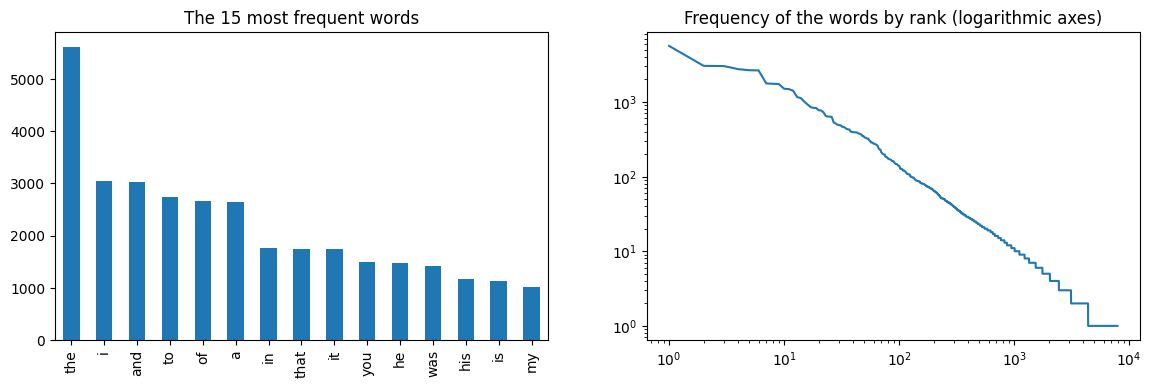

share of the text covered by the 10 most frequent words: 0.25
words that appear only once: 3522 (44% of the different words)


In [3]:
counts = pd.Series(words).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
counts.head(15).plot(kind="bar", ax=axes[0], title="The 15 most frequent words")
axes[1].loglog(np.arange(1, len(counts) + 1), counts.values); axes[1].set_title("Frequency of the words by rank (logarithmic axes)")
plt.show()

print("share of the text covered by the 10 most frequent words:", round(counts.head(10).sum() / len(words), 3))
print("words that appear only once:", (counts == 1).sum(), f"({(counts == 1).mean():.0%} of the different words)")

Word frequencies follow the typical rule of natural language: the 10 most frequent words ("the", "and", "i", "to", "of" and so on) cover 25% of the text, while 44% of the 7,917 different words appear only once. This has two consequences for a next word model: a model that always proposes the most frequent words is right sometimes, and many words are too rare for a model to learn anything about them.

## Reference Reproduction

The reference represents each sequence of 5 words by 5 one-hot vectors with one position per different word of the book, and each target by one one-hot vector. The memory that this needs (1 byte per value) is computed here.

In [4]:
sequences, vocabulary_size = len(words) - 5, len(set(words))
print("one-hot inputs:", round(sequences * 5 * vocabulary_size / 1e9, 1), "GB | one-hot targets:", round(sequences * vocabulary_size / 1e9, 1), "GB")

one-hot inputs: 4.2 GB | one-hot targets: 0.8 GB


The reference needs about 5 GB just for the one-hot arrays, and its output layer has one neuron for each of the 7,917 different words, most of which appear once or twice. Other points of the reference: the legal text of Project Gutenberg is part of its corpus, the LSTM is trained for 2 epochs although the text says 20, only the training curves are shown (no accuracy on a text that was not used for training, no comparison with a simple model), the function that turns a sentence into numbers raises an error for any word that is not in the book (`unique_word_index[word]`), and the article defines two different versions of that function (one for characters and one for words).

## Feature Engineering

The book is split in the order of the story: the first 80% of the words for training, the next 10% for validation (used to stop the training) and the last 10% for the test, so the model is tested on the last stories, with words and names that appear only there. The vocabulary is built with the training words only: words that occur at least 3 times become numbers from 1 to V, and all other words become the number 0 ("unknown"). Each example is a sequence of five word numbers and the number of the next word.

In [5]:
train_end, val_end = int(len(words) * 0.8), int(len(words) * 0.9)

train_counts = pd.Series(words[:train_end]).value_counts()
vocabulary = train_counts[train_counts >= 3].index
word_to_id = {word: i + 1 for i, word in enumerate(vocabulary)}
ids = pd.Series(words).map(word_to_id).fillna(0).astype(int).values

windows = np.lib.stride_tricks.sliding_window_view(ids, 6)
x, y = windows[:, :5], windows[:, 5]
target_position = np.arange(5, len(ids))
train, val, test = target_position < train_end, (target_position >= train_end) & (target_position < val_end), target_position >= val_end

V = len(vocabulary) + 1
print("vocabulary:", V - 1, "words + 1 unknown | examples: train", train.sum(), "validation", val.sum(), "test", test.sum())
print("share of the test targets that are unknown words:", round((y[test] == 0).mean(), 3))

vocabulary: 2742 words + 1 unknown | examples: train 84759 validation 10596 test 10596
share of the test targets that are unknown words: 0.099


## Model Training

Three kinds of models are compared.

- **Counting models:** the most frequent word of the training text, the most frequent word after the previous word (bigram), and the most frequent word after the two previous words (trigram), each falling back to the shorter context when the context was never seen in training.
- **LSTM:** an embedding layer (each word number becomes a vector of 64 values, instead of a one-hot vector of thousands of values), an LSTM layer with 128 units and an output layer with one probability per word, trained with early stopping on the validation loss. The Embedding layer is not in the course; it is the standard way to feed words to a network without one-hot vectors.

In [6]:
def top_words(context, target, k=3):
    table = pd.DataFrame({"context": context, "target": target}).value_counts().reset_index(name="n")
    return table[table["target"] != 0].sort_values("n", ascending=False).groupby("context")["target"].apply(lambda s: s.head(k).tolist())

overall = top_words(np.zeros(train.sum(), dtype=int), y[train])[0]
bigram_key = lambda a: a[:, 4]
trigram_key = lambda a: a[:, 3] * V + a[:, 4]
bigram_top = top_words(bigram_key(x[train]), y[train])
trigram_top = top_words(trigram_key(x[train]), y[train])

def counting_predictions(kind):
    fallback = pd.Series([overall] * test.sum())
    bigram = pd.Series(bigram_key(x[test])).map(bigram_top)
    trigram = pd.Series(trigram_key(x[test])).map(trigram_top)
    if kind == "most frequent word": return fallback
    if kind == "bigram": return bigram.combine_first(fallback)
    return trigram.combine_first(bigram).combine_first(fallback)

def accuracy(predicted_lists):
    known = y[test] != 0
    first = np.array([p[0] for p in predicted_lists])[known] == y[test][known]
    top3 = np.array([target in p for p, target in zip(predicted_lists, y[test])])[known]
    return {"top-1 accuracy": first.mean(), "top-3 accuracy": top3.mean()}

In [7]:
model = Sequential([Input(shape=(5,)), Embedding(V, 64), LSTM(128), Dense(V, activation="softmax")])
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy")

history = model.fit(x[train], y[train], validation_data=(x[val], y[val]), batch_size=128, epochs=20,
                    callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)], verbose=0)
print("epochs trained:", len(history.history["loss"]), "| training loss:", round(history.history["loss"][-1], 2), "| best validation loss:", round(min(history.history["val_loss"]), 2))

I0000 00:00:1790341769.003192   72647 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1790341773.213276   72718 cuda_dnn.cc:461] Loaded cuDNN version 92400


epochs trained: 12 | training loss: 4.28 | best validation loss: 4.74


## Evaluation

In [8]:
probabilities = model.predict(x[test], batch_size=512, verbose=0)
probabilities[:, 0] = 0                                   # the unknown word is never proposed
lstm_top3 = np.argsort(-probabilities, axis=1)[:, :3].tolist()

results = {kind: accuracy(counting_predictions(kind)) for kind in ["most frequent word", "bigram", "trigram with back-off"]}
results["LSTM"] = accuracy(lstm_top3)

test_loss = model.evaluate(x[test], y[test], batch_size=512, verbose=0)
print("perplexity of the LSTM on the test text:", round(np.exp(test_loss), 1), "| perplexity of a uniform guess:", V)
pd.DataFrame(results).T.round(3)

perplexity of the LSTM on the test text: 108.0 | perplexity of a uniform guess: 2743


,top-1 accuracy,top-3 accuracy
most frequent word,0.052,0.120
bigram,0.144,0.263
trigram with back-off,0.146,0.241
LSTM,0.151,0.271


The LSTM reaches a top-1 accuracy of 15.0% and a top-3 accuracy of 26.9% on the last stories of the book, and a perplexity of 109 (a guess among all 2,743 words would have a perplexity of 2,743). The comparison with the counting models shows how little the network adds: proposing the most frequent word after the previous word (bigram) gives 14.4% and 26.4%, and the trigram model with back-off 14.6% and 24.6%. The differences of the LSTM to the bigram model (0.6 and 0.5 points) are about the size of the statistical error of a test with about 9,500 predictions (a standard error of about 0.35 points for a 15% accuracy), so they cannot be called real. Always proposing the most frequent words gives only 5.2% and 12.0%.

The limit is the data and not the model: a single book of 106,000 words is too small to learn the meaning of words, and a next word depends on the sentence much more than on the five previous words. The test also comes from the last stories, with other characters and 9.9% of the words unknown to the model; the model was never scored on them. The proposals for the examples are sensible: "it is not a lack" is followed by "of", "the door was opened by a" by "small, little, man", but "sherlock holmes said to me" gets the very general "i, that, and".

The last test uses the reference sentence and two other prompts. The five words are turned into numbers with the vocabulary; a word that is not in it becomes the unknown word.

In [9]:
id_to_word = {i: w for w, i in word_to_id.items()}
prompts = ["it is not a lack", "i have no doubt that", "sherlock holmes said to me", "the door was opened by a"]

def propose(prompt):
    numbers = np.array([[word_to_id.get(w, 0) for w in prompt.split()]])
    p = model.predict(numbers, verbose=0)[0]; p[0] = 0
    return [id_to_word[i] for i in np.argsort(-p)[:3]]

pd.DataFrame({"prompt": prompts, "three proposed words": [", ".join(propose(p)) for p in prompts]})

,prompt,three proposed words
0,it is not a lack,"of, and, in"
1,i have no doubt that,"i, the, you"
2,sherlock holmes said to me,"that, i, and"
3,the door was opened by a,"small, man, few"


## Conclusion

**Reference approach.** The reference cuts the book into sequences of five words, one-hot encodes every word (about 5 GB of arrays for 7,917 different words), trains an LSTM for 2 epochs and shows the training curves. It includes the Project Gutenberg license in its corpus, never measures how often the proposed word is right, and does not compare with a simple model.

**Our approach.** The header and license were removed, the book was split in the order of the story (first 80% of the words for training, 10% for validation, the last 10% for the test), the vocabulary was built from the training words with a threshold of 3 occurrences (2,742 words, the others are "unknown"), and the words were given to the network with an Embedding layer instead of one-hot vectors. The proposals are scored on the test text (positions whose next word is in the vocabulary):

| Model | Top-1 accuracy | Top-3 accuracy |
|---|---|---|
| Most frequent word | 5.2% | 12.0% |
| Bigram (after the previous word) | 14.4% | 26.4% |
| Trigram with back-off | 14.6% | 24.6% |
| LSTM (embedding 64, 128 units) | 15.0% | 26.9% |

The perplexity of the LSTM on the test text is 109. The LSTM is not clearly better than counting the words that follow the previous word: the differences are within the statistical error. On a text of this size (106,000 words), the extra capacity of a neural network cannot be used.

**Limitations.** Only one book and one split were used, and each model was trained once. Words outside the training vocabulary (9.9% of the test targets) were excluded from the accuracy and are never proposed. The perplexity is only available for the LSTM, because the counting models were not smoothed. Sampling the next word with some randomness (as a keyboard does) was not evaluated, and no tuning of the sequence length, the number of units or the vocabulary threshold was made. A much larger text or a pre-trained language model would be needed for good proposals.